# LIBRARIES IMPORTATION

# NURSERY DATASET

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score, classification_report, 
                            confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max.column', None)

# PLOT STYLE

In [3]:
sns.set_context('notebook')
plt.style.use('tableau-colorblind10')

An algorithm that predicts school application outcome based on the available attributes.

# DATA IMPORTATION AND EXPLORATION

In [4]:
df = pd.read_csv("nursery.csv")
df.head()

,id,parents,has_nurs,form,children,housing,finance,social,health,decision
0,0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        12960 non-null  int64
 1   parents   12960 non-null  str  
 2   has_nurs  12960 non-null  str  
 3   form      12960 non-null  str  
 4   children  12960 non-null  str  
 5   housing   12960 non-null  str  
 6   finance   12960 non-null  str  
 7   social    12960 non-null  str  
 8   health    12960 non-null  str  
 9   decision  12960 non-null  str  
dtypes: int64(1), str(9)
memory usage: 1012.6 KB


In [6]:
df.drop(['id'], axis = 1, inplace = True)

In [7]:
for col in df.columns:
    print(f'{col} distinct values are \n {df[col].unique()}')

parents distinct values are 
 <StringArray>
['usual', 'pretentious', 'great_pret']
Length: 3, dtype: str
has_nurs distinct values are 
 <StringArray>
['proper', 'less_proper', 'improper', 'critical', 'very_crit']
Length: 5, dtype: str
form distinct values are 
 <StringArray>
['complete', 'completed', 'incomplete', 'foster']
Length: 4, dtype: str
children distinct values are 
 <StringArray>
['1', '2', '3', 'more']
Length: 4, dtype: str
housing distinct values are 
 <StringArray>
['convenient', 'less_conv', 'critical']
Length: 3, dtype: str
finance distinct values are 
 <StringArray>
['convenient', 'inconv']
Length: 2, dtype: str
social distinct values are 
 <StringArray>
['nonprob', 'slightly_prob', 'problematic']
Length: 3, dtype: str
health distinct values are 
 <StringArray>
['recommended', 'priority', 'not_recom']
Length: 3, dtype: str
decision distinct values are 
 <StringArray>
['recommend', 'priority', 'not_recom', 'very_recom', 'spec_prior']
Length: 5, dtype: str


In [8]:
missing = df.isna().sum()
missing[missing > 0]

Series([], dtype: int64)

In [9]:
df.duplicated().sum()

np.int64(0)

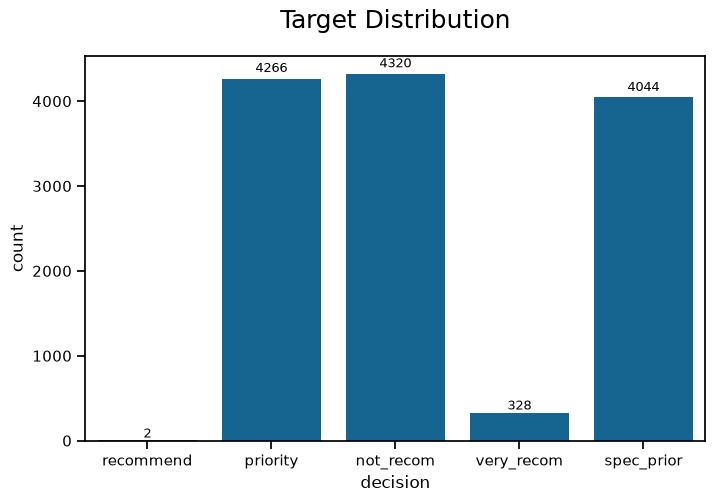

In [10]:
plt.figure(figsize = (8, 5))
g = sns.countplot(data = df, x = 'decision')
for bar in g.patches:
    height = bar.get_height()
    width = bar.get_width() / 2
    plt.text(bar.get_x() + width, height + (height * 0.01), f'{int(height)}', ha = 'center',
             fontsize = 9, va = 'bottom')
g.set_title('Target Distribution', fontsize = 18, y = 1.05)
plt.show()

# PREPROCESSING

In [11]:
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
df.head()

,parents,has_nurs,form,children,housing,finance,social,health,decision
0,2,3,0,0,0,0,0,2,2
1,2,3,0,0,0,0,0,1,1
2,2,3,0,0,0,0,0,0,0
3,2,3,0,0,0,0,2,2,2
4,2,3,0,0,0,0,2,1,1


In [12]:
df['decision'].value_counts()

decision
0    4320
1    4266
3    4044
4     328
2       2
Name: count, dtype: int64

In [13]:
X = df.drop(['decision'], axis = 1)
y = df['decision']

# DATA SPLITTING

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(10368, 8) (2592, 8) (10368,) (2592,)


Handle class imbalance

There is class imbalance and to handle this, I used SMOTE (Synthetic Minority Over-sampling Technique); an algorithm used to address imbalance datasets, its main purpose is to synthesize new realistic samples for the minority class so the model can learn patterns of that class more.

In [15]:
smote = SMOTE(sampling_strategy = 'minority', random_state = 42, k_neighbors = 1)
X_train_resample, y_train_resample = smote.fit_resample(X_train, y_train)

# MODEL TRAINING AND EVALUATION

In [16]:
# Looking for optimal k value 
train_accuracies = {}
test_accuracies = {}
neighbors = np.arange(1, 16)
for neighbor in neighbors:
    model = KNeighborsClassifier(n_neighbors = neighbor)
    model.fit(X_train_resample, y_train_resample)
    train_accuracies[neighbor] = model.score(X_train_resample, y_train_resample)
    test_accuracies[neighbor] =  model.score(X_test, y_test)

In [17]:
print(f'Train Accuracies \n {train_accuracies}')

Train Accuracies 
 {np.int64(1): 1.0, np.int64(2): 0.9092027203009695, np.int64(3): 0.9674432064824193, np.int64(4): 0.9662856316017943, np.int64(5): 0.9759079727969903, np.int64(6): 0.9763420633772247, np.int64(7): 0.9814064534799595, np.int64(8): 0.9803212270293734, np.int64(9): 0.9847344812617567, np.int64(10): 0.9785848647084359, np.int64(11): 0.9793806974388656, np.int64(12): 0.9721458544349587, np.int64(13): 0.9722182028649978, np.int64(14): 0.9680219939227319, np.int64(15): 0.9658515410215598}


In [18]:
print(f'Test Accuracies \n {test_accuracies}')

Test Accuracies 
 {np.int64(1): 0.7885802469135802, np.int64(2): 0.7959104938271605, np.int64(3): 0.908179012345679, np.int64(4): 0.9239969135802469, np.int64(5): 0.9382716049382716, np.int64(6): 0.9456018518518519, np.int64(7): 0.9544753086419753, np.int64(8): 0.9544753086419753, np.int64(9): 0.9594907407407407, np.int64(10): 0.9556327160493827, np.int64(11): 0.9556327160493827, np.int64(12): 0.9432870370370371, np.int64(13): 0.9448302469135802, np.int64(14): 0.9390432098765432, np.int64(15): 0.9390432098765432}


Instantiate the model, with the parameter weight = 'distance', which enables the model to focus on its closest neighbor, 
This is because the data is imbalanced. 

In [19]:
model = KNeighborsClassifier(n_neighbors = 7, weights = "distance")
model.fit(X_train_resample, y_train_resample)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](5,)","[0,1,2,3,4]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [20]:
# now your model has to predict using unseen data
prediction = model.predict(X_test)

In [21]:
print(f'Accuracy score {accuracy_score(y_test, prediction):.2f}')
print(f'Precision score {precision_score(y_test, prediction, average = 'weighted'):.2f}')
print(f'Recall score {recall_score(y_test, prediction, average = 'weighted'):.2f}')
print(f'F1 score {f1_score(y_test, prediction, average = 'weighted'):.2f}')

Accuracy score 0.95
Precision score 0.96
Recall score 0.95
F1 score 0.95


In [22]:
print(f'Classification Report \n {classification_report(y_test, prediction, zero_division = 0)}')

Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       864
           1       0.91      0.96      0.93       853
           2       0.00      0.00      0.00         0
           3       0.95      0.94      0.95       809
           4       1.00      0.48      0.65        66

    accuracy                           0.95      2592
   macro avg       0.77      0.68      0.71      2592
weighted avg       0.96      0.95      0.95      2592



Text(0.5, 1.0, 'Confusion Matrix')

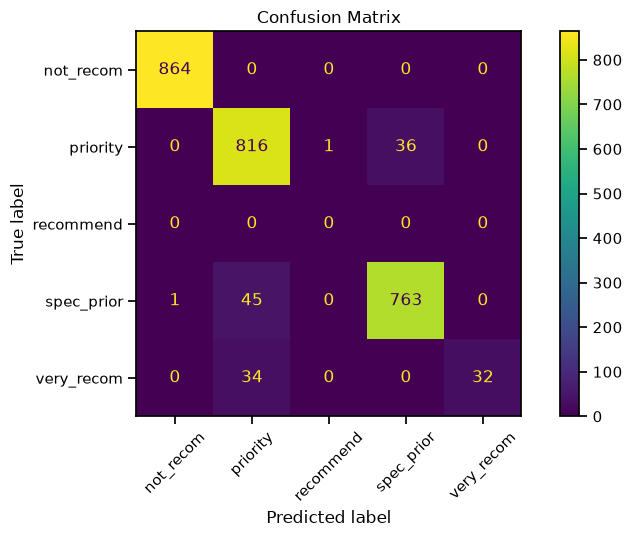

In [23]:
cm = confusion_matrix(y_test, prediction)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = le.classes_)
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
disp.plot(ax = ax, xticks_rotation = 45)
plt.title('Confusion Matrix')

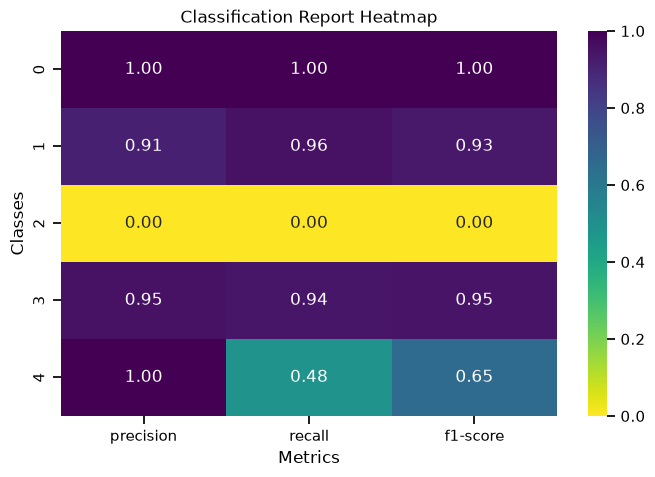

In [24]:
cr = classification_report(y_test, prediction, zero_division = 0, output_dict = True)
# Convert classification report into a data frame.
cr_df = pd.DataFrame(cr).transpose()
# To drop support column and last three rows (accuracy, macro avg and weighted avg)
heatmap = cr_df.iloc[: -3, :].drop(['support'], axis = 1)
plt.figure(figsize = (8, 5))
sns.heatmap(heatmap, annot = True, fmt = '.2f', cmap = 'viridis_r')
plt.title("Classification Report Heatmap")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.show()

# MY THOUGHT

Project: Nursery Dataset Classification with KNN.

what is it about? 

I am used KNN, a supervised learning classification algorithm to predict the type of **Nursery Recommendation** a child
gets based on family and social factor.

How it works?

I imported all libraries that i need to work with such as pandas, numpy, matplotlib, seaborn and scikit learn.

I loaded the dataset and went through it to understand it, checking each categorical distinct value. 

I checked for missing values, duplicates, and I checked the target column distribution.

I preprocess the data to convert categorical feature values to numbers, because machines only understand numbers.

I split my data into a training set and a testing set, which I used to fit and evaluate the performance of the algorithm used.

I applied **SMOTE** to the training set. Its main purpose is to synthesize new realistic samples for the minority class so the model can learn patterns of that class more.

I used a for loop to train KNN, which I used to select the best K value from the given results.

Finally trained to look at past examples and learn data. 

After aplying smote, KNN still did not recognize class 2, because it had only two instances.

The model can now take a new child's information and predict the nursery recommendation. 

KNN works like this: To decide for a new child, look at the k closest children in the dataset. The most common recommendation among those neighbors is the prediction for the new child.

# An algorithm to classify faults in plate production.

# DATA  LOADING AND EXPLORATION

In [25]:
plate = pd.read_csv("php5s7Ep8.csv")
plate.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,target
0,42,50,270900,270944,267,17,44,24220,76,108,1687,1,0,80,0.0498,0.2415,0.1818,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,1687,1,0,80,0.7647,0.3793,0.2069,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,1623,1,0,100,0.9710,0.3426,0.3333,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,1353,0,1,290,0.7287,0.4413,0.1556,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,1353,0,1,185,0.0695,0.4486,0.0662,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry


In [26]:
plate.rename(columns = {
    'V1': 'X_Minimum', 'V2': 'X_Maximum', 'V3': 'Y_Minimum', 'V4': 'Y_Maximum', 'V5': 'Pixels_Areas', 
    'V6': 'X_Perimeter', 'V7': 'Y_Perimeter', 'V8': 'Sum_of_Luminosity', 'V9': 'Minimum_of_Luminosity',
    'V10': 'Maximum_of_Luminosity', 'V11': 'Length_of_Conveyer', 'V12': 'TypeOfSteel_A300', 'V13': 'TypeOfSteel_A400',
    'V14': 'Steel_Plate_Thickness', 'V15': 'Edges_Index', 'V16': 'Empty_Index', 'V17': 'Square_Index',
    'V18': 'Outside_X_Index', 'V19': 'Edges_X_Index', 'V20': 'Edges_Y_Index', 'V21': 'Outside_Global_Index',
    'V22': 'LogOfAreas', 'V23': 'Log_X_Index', 'V24': 'Log_Y_Index', 'V25': 'Orientation_Index', 
    'V26': 'Luminosity_Index', 'V27': 'SigmoidOfAreas'},  inplace = True)

In [27]:
plate.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'target'],
      dtype='str')

In [28]:
plate.info()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empty_Index    

In [29]:
plate.isna().sum()

X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
target                   0
dtype: int64

In [30]:
plate.duplicated().sum()

np.int64(0)

In [31]:
num_cols = plate.select_dtypes(include = ['int', 'float'])
num_cols.head(2)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
0,42,50,270900,270944,267,17,44,24220,76,108,1687,1,0,80,0.0498,0.2415,0.1818,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822
1,645,651,2538079,2538108,108,10,30,11397,84,123,1687,1,0,80,0.7647,0.3793,0.2069,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984


# DATA CLEANING

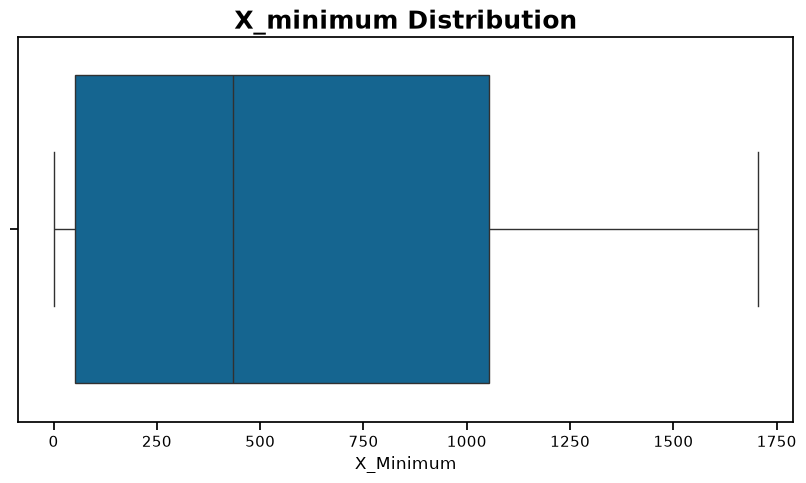

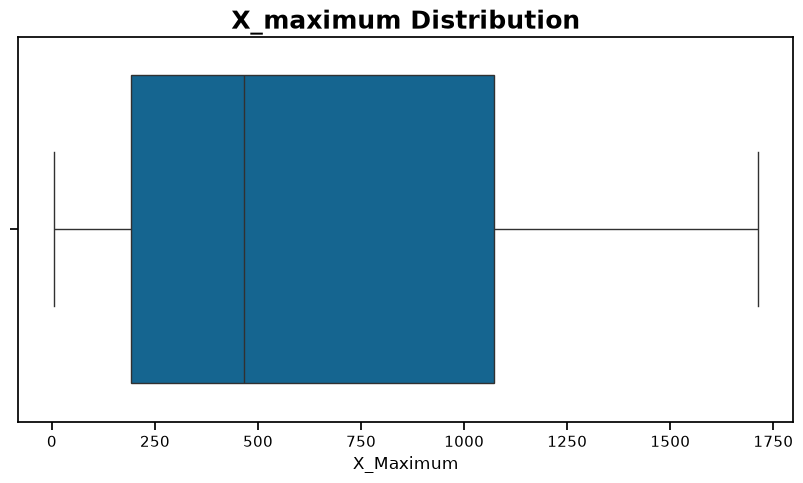

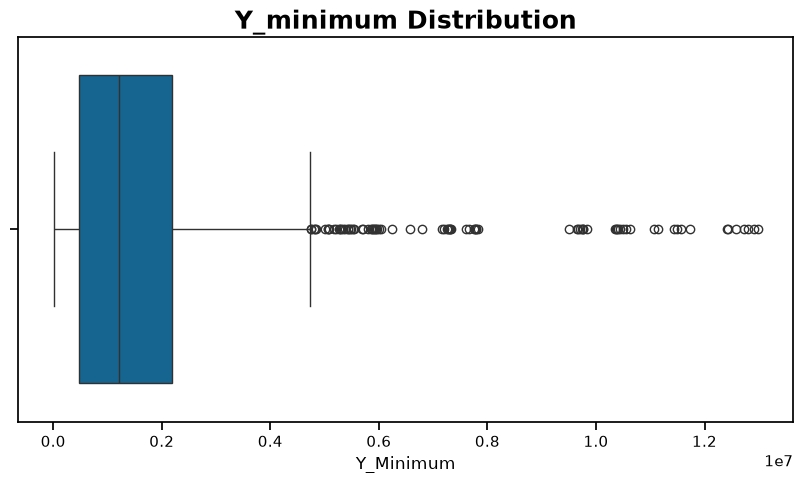

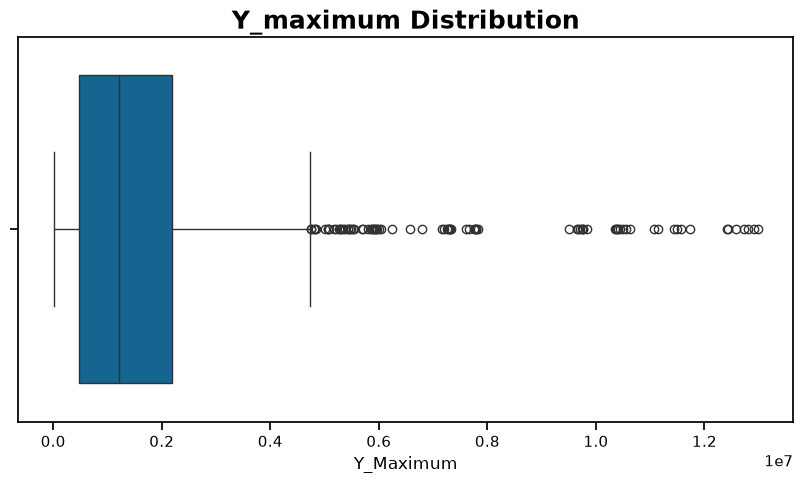

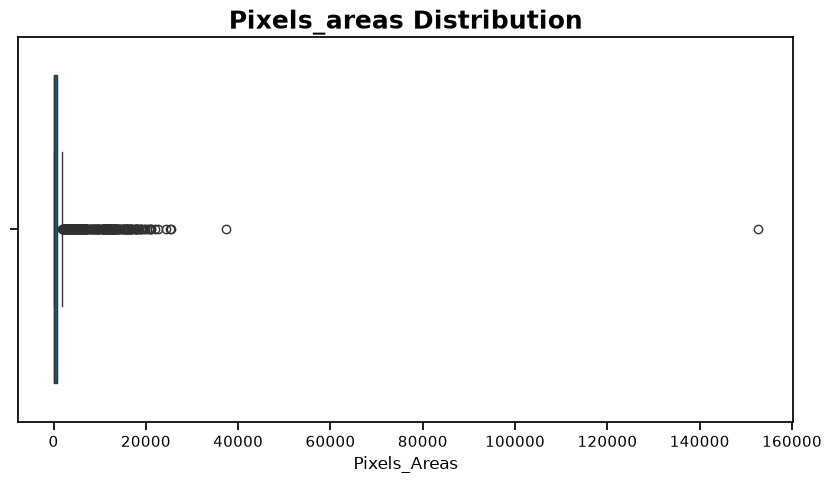

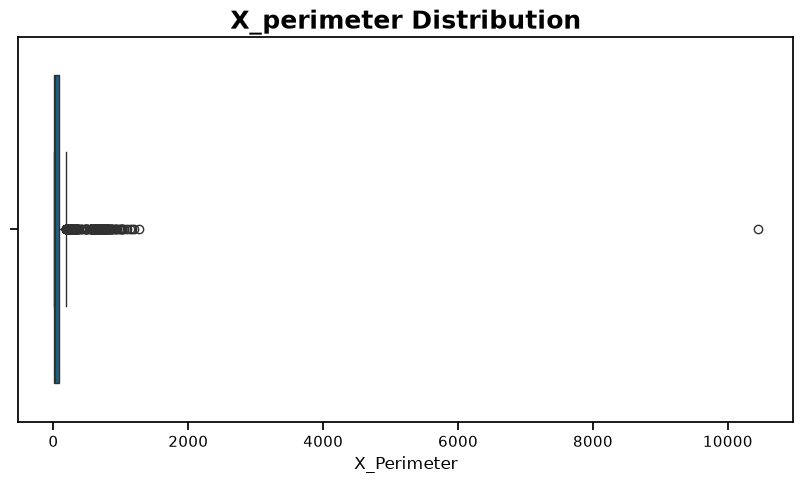

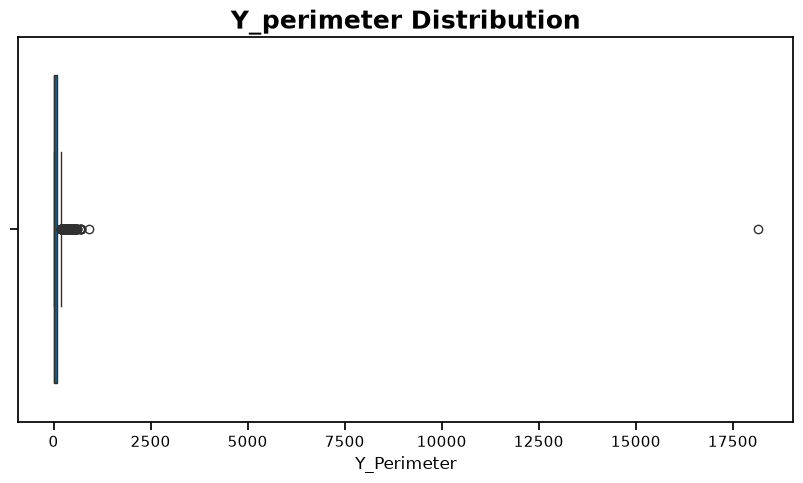

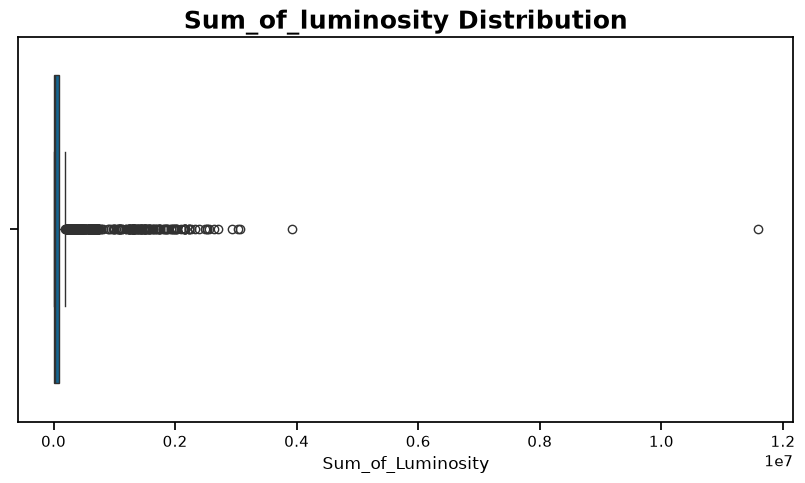

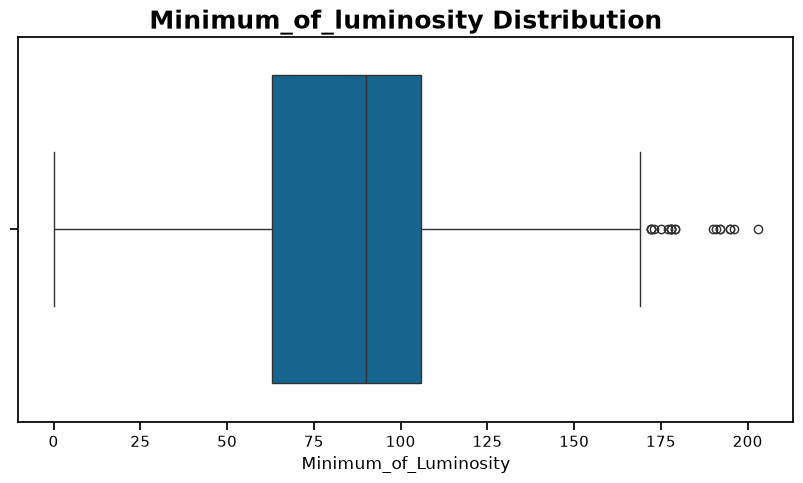

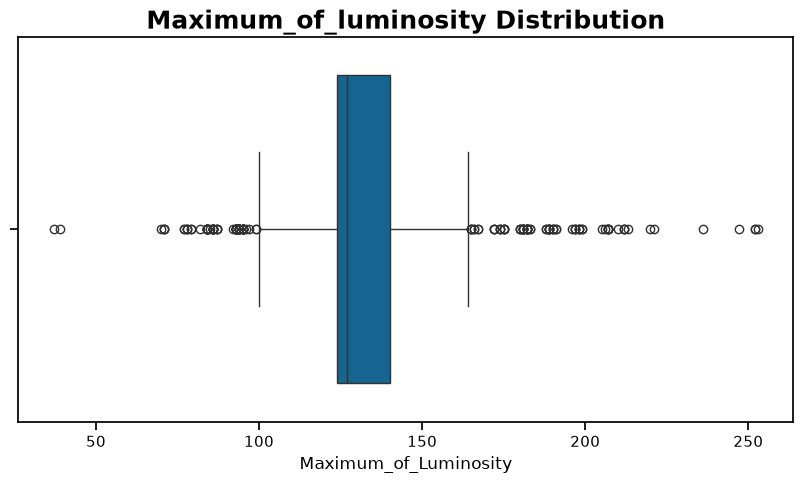

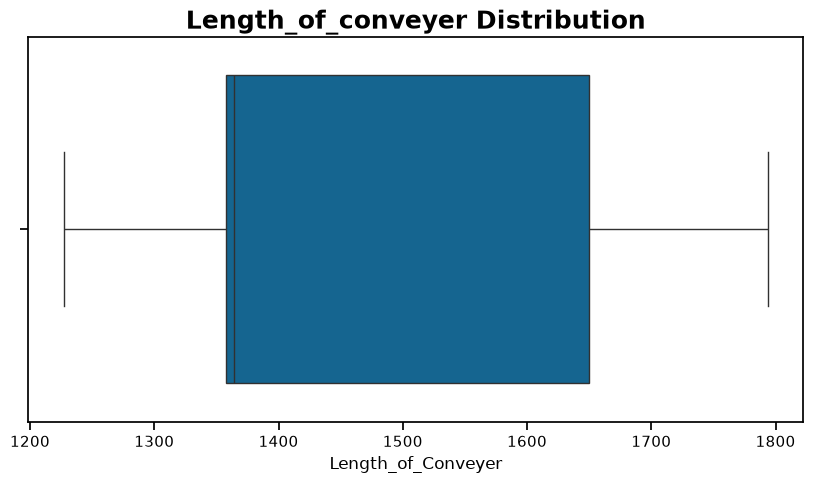

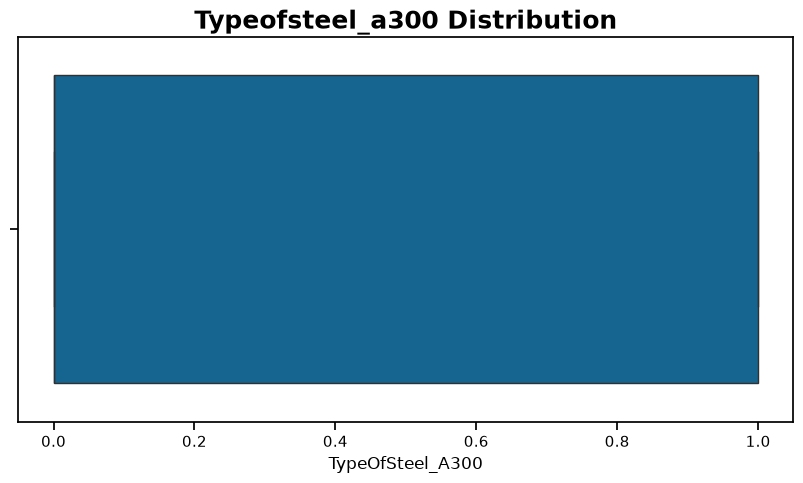

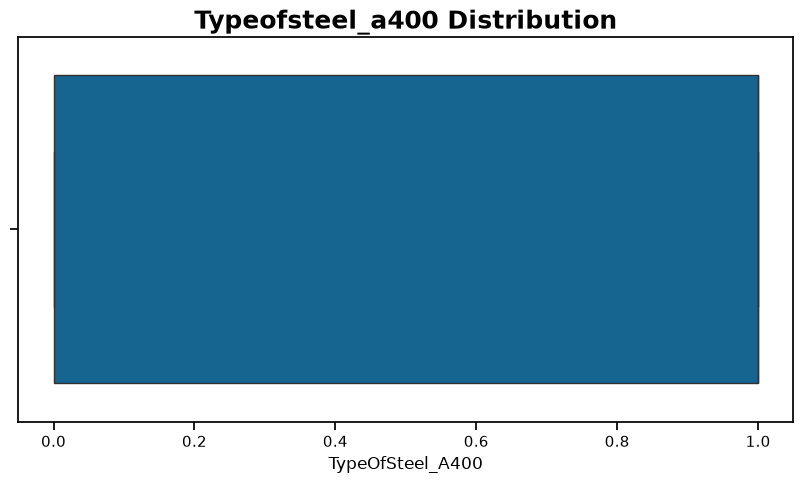

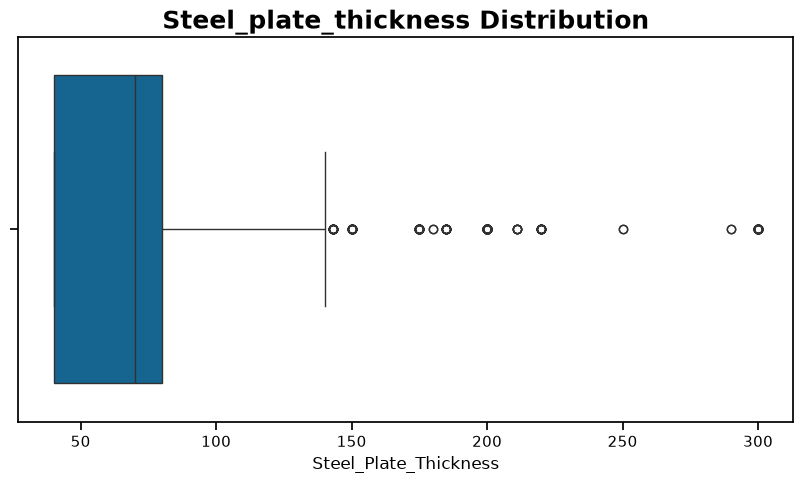

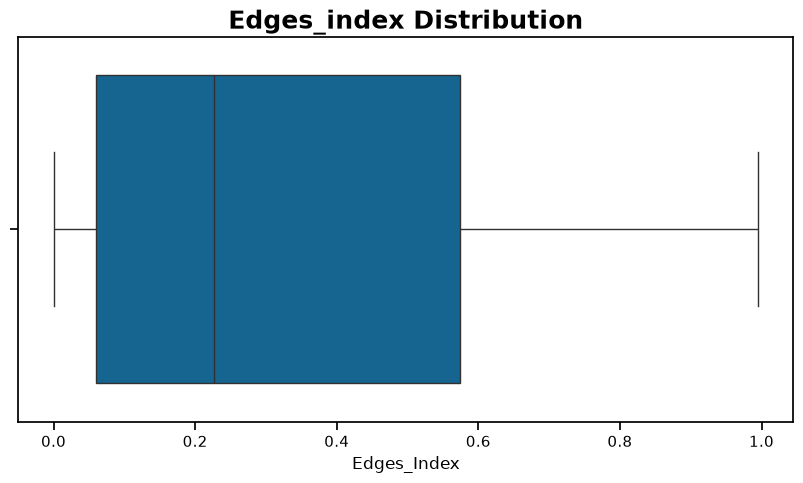

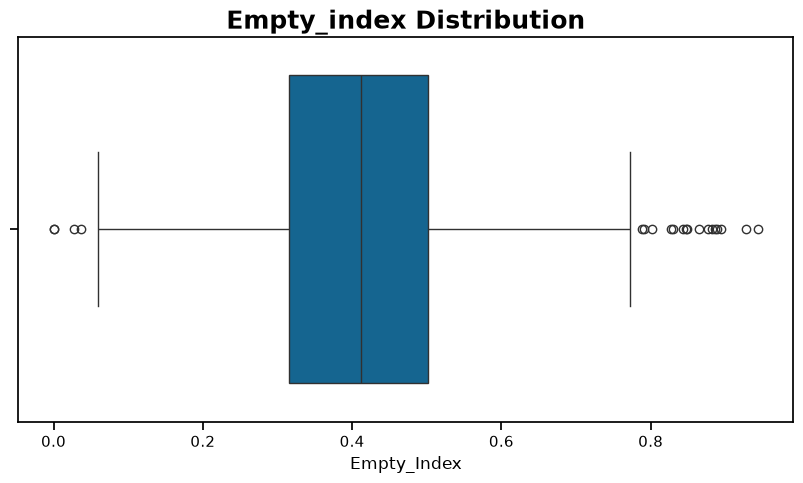

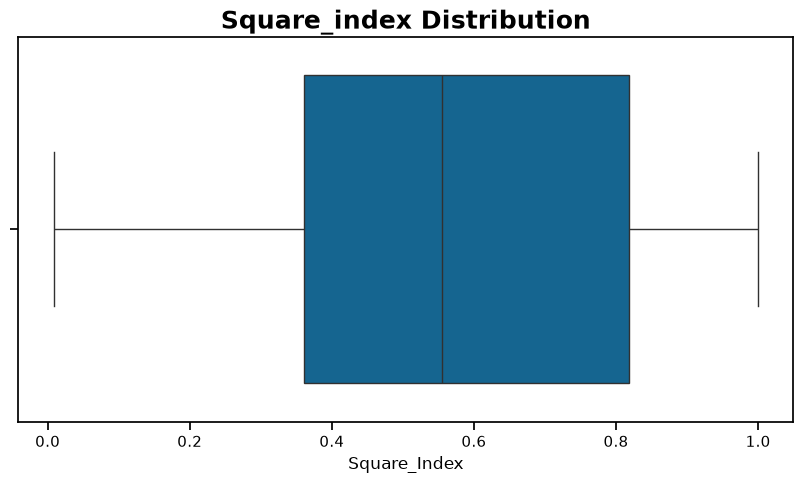

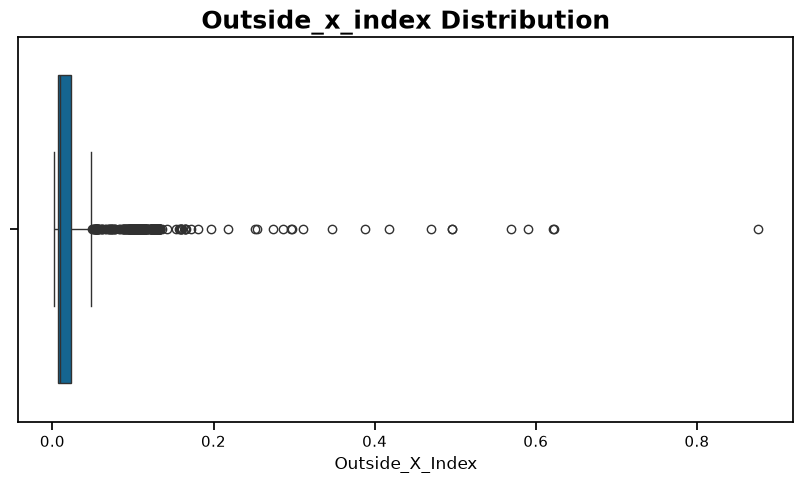

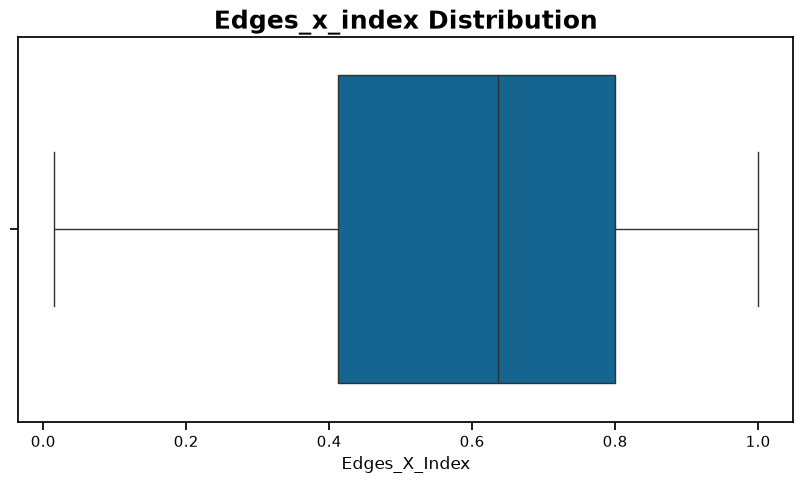

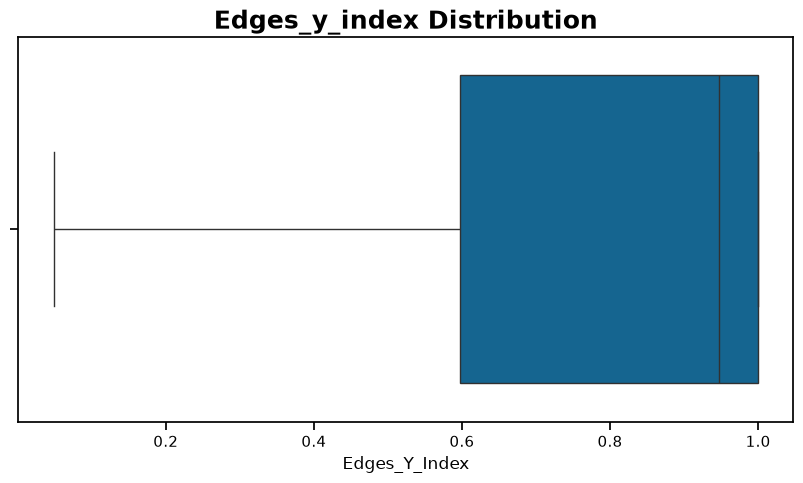

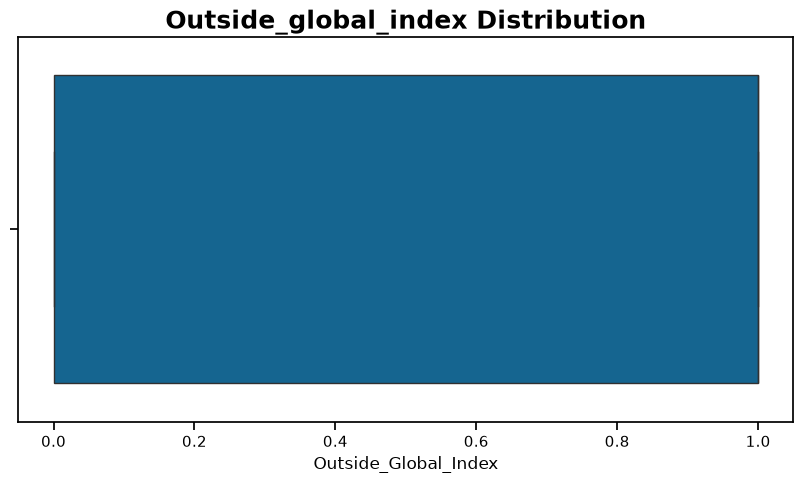

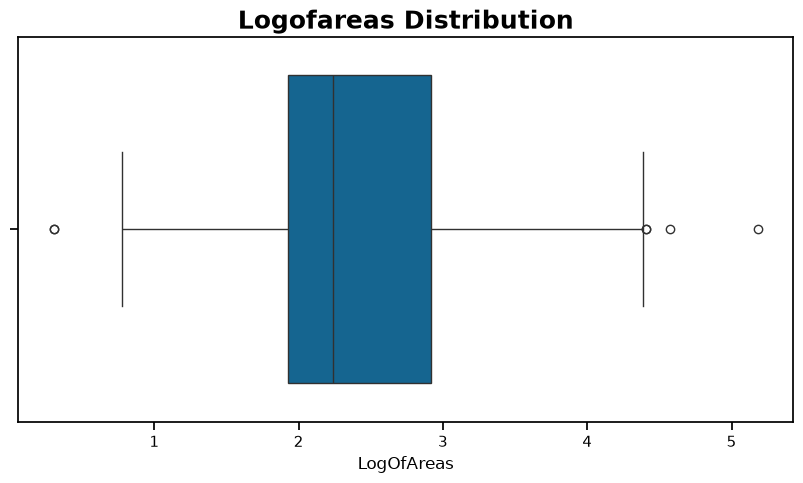

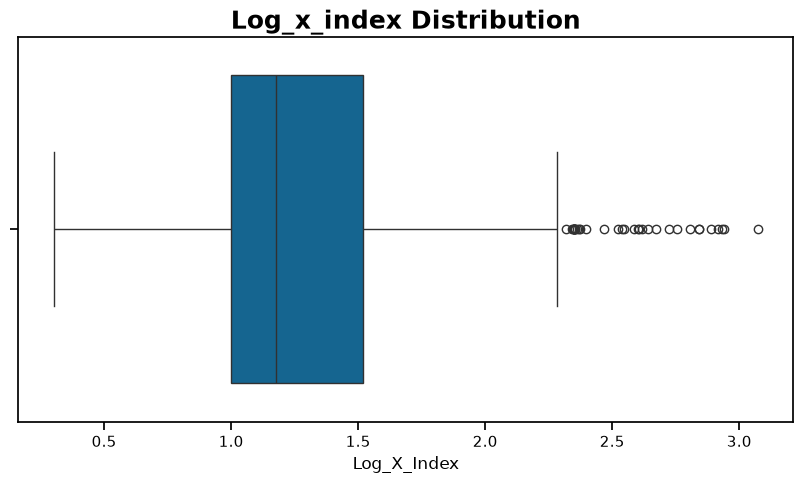

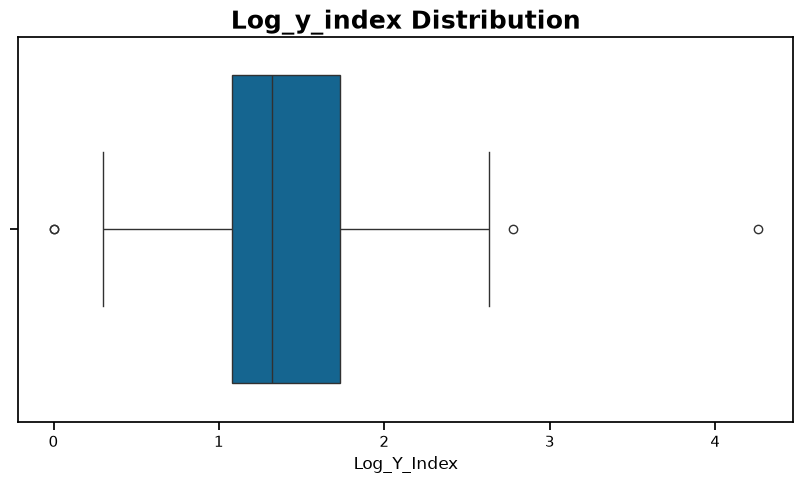

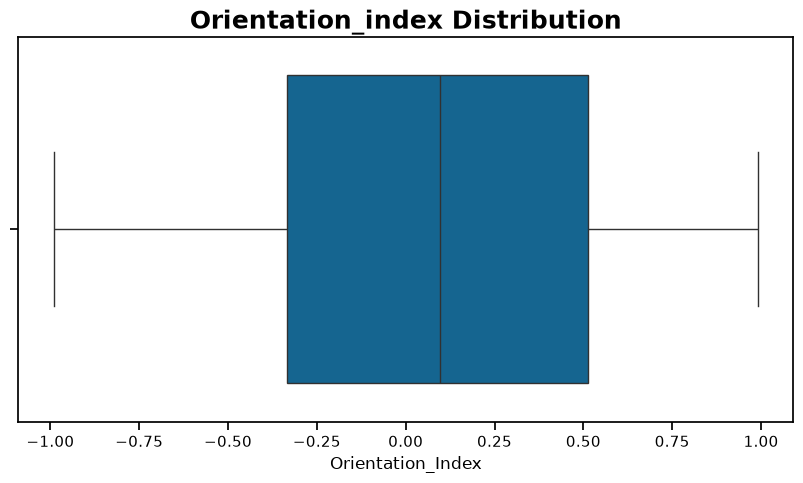

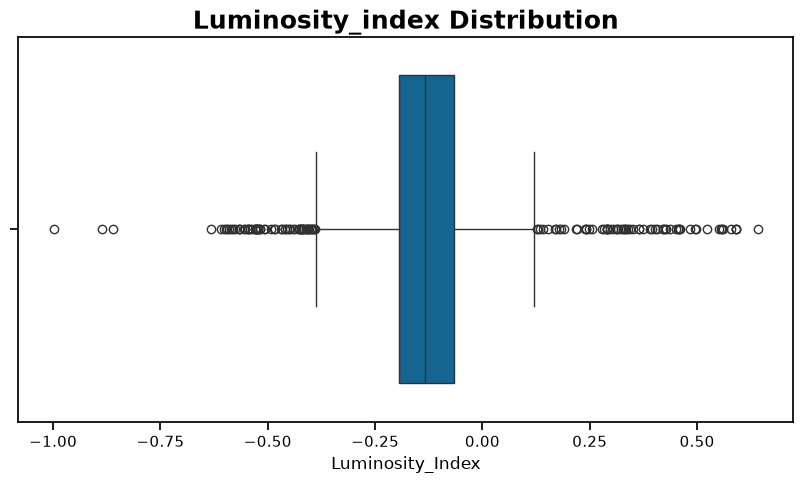

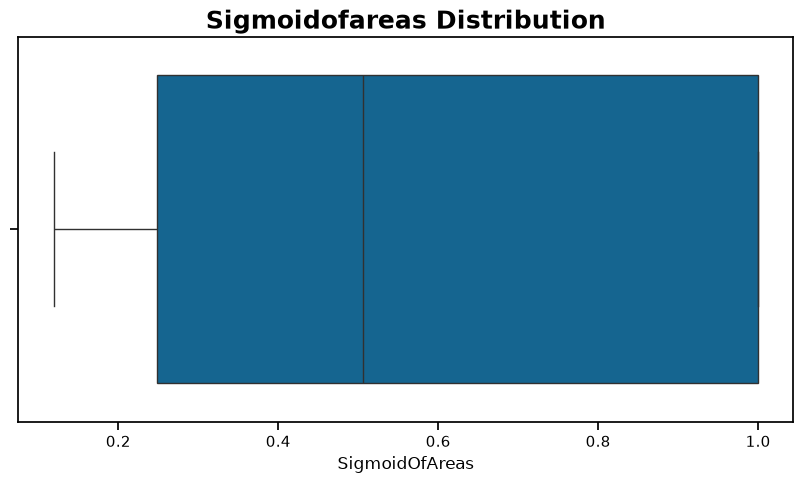

In [32]:
# checking for outliers
for col in num_cols:
    plt.figure(figsize = (10, 5))
    g = sns.boxplot(plate[col], orient = 'h')
    g.set_title(f'{col.capitalize()} Distribution', fontsize = 18, fontweight = 'bold')
plt.show()

In [33]:
mild = ['minimum_of_luminosity', 'steel_plate_thickness', 'edges_index', 'empty_index', 'log_y_index', 'logofareas']
medium = ['y_minimum', 'y_maximum',  'maximum_of_luminosity' 'log_x_index']
extreme = ['X_perimeter', 'y_perimeter', 'pixels_areas', 'outside_x_index', 'sum_of_luminosity', 'luminosity_index']

The outliers are too much but was reduced to an extent

In [36]:
plate["target"].unique()

<StringArray>
[      'Pastry',    'Z_Scratch',    'K_Scratch',       'Stains',
    'Dirtiness',        'Bumps', 'Other_Faults']
Length: 7, dtype: str

# DATA PREPROCESSING 

In [37]:
le = LabelEncoder()
plate['target'] = le.fit_transform(plate['target'])

In [38]:
X = plate.drop(['target'], axis = 1)
y = plate['target']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, 
                                                   stratify = y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1552, 27) (389, 27) (1552,) (389,)


In [40]:
smote = SMOTE(random_state = 21)
X_train_resample, y_train_resample = smote.fit_resample(X_train, y_train)

In [41]:
X_train_resample.columns

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas'],
      dtype='str')

In [42]:
ss = StandardScaler()
X_train_scaled = pd.DataFrame(ss.fit_transform(X_train_resample), columns = X_train_resample.columns, index = X_train_resample.index)
X_test_scaled = pd.DataFrame(ss.transform(X_test), columns = X_test.columns, index = X_test.index)

I noticed that when i scale, it convert tha name of the columns into numbers. 
This is because numpy arrays does not store column names and row indices.
To handle this, i had to tell pandas to keep the column names after scaling.

In [43]:
X_test_scaled.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
1710,0.452668,0.447444,-0.440421,-0.440370,-0.089035,0.366043,0.861087,-0.045768,0.781746,0.818792,-0.337990,-0.675919,0.820387,3.532112,1.323495,2.098007,-1.361868,-0.169042,-1.720430,0.106968,0.873023,0.914748,0.359247,1.640684,1.325278,0.732891,1.443642
863,0.001814,-0.055293,0.274202,0.274187,-0.382402,-0.423297,-0.461829,-0.367045,0.679143,0.182006,-0.583094,-0.675919,0.820387,0.656169,1.736238,-0.109325,0.152829,-0.388743,0.058971,0.691149,0.873023,-0.596635,-0.658615,-0.407906,0.541973,0.287630,-0.911758
1174,0.860290,0.853500,-0.617225,-0.617242,-0.368474,-0.411059,-0.481142,-0.357816,-0.723097,-0.200065,1.898583,1.479467,-1.218937,-0.062817,1.285055,-0.763412,1.238774,-0.339000,1.306592,0.691149,-1.294112,-0.307292,-0.119277,-0.548068,-0.581387,-0.708943,-0.698701
1815,-0.129943,-0.192793,0.392067,0.392054,-0.370252,-0.411059,-0.423204,-0.355168,0.473937,0.309364,2.051773,1.479467,-1.218937,0.656169,0.901304,-1.375245,-0.329898,-0.413615,-0.263236,0.691149,0.873023,-0.336835,-0.658615,-0.179121,0.791609,0.168793,-0.794667
370,0.683242,0.662289,-0.680343,-0.680361,-0.377364,-0.429416,-0.500454,-0.351411,1.705173,3.238579,-0.406926,-0.675919,0.820387,-0.781803,0.828008,-1.508767,1.436425,-0.347290,1.241445,0.691149,-1.294112,-0.473772,-0.351658,-0.714000,-0.479174,3.089315,-0.918397


# MODELLING AND FEATURE SELECTION

In [44]:
log_reg = LogisticRegression()

selector = RFE(estimator = log_reg, n_features_to_select = 19)
selector.fit(X, y)
selected_features = X.columns[selector.support_]
print(selected_features)

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_X_Index',
       'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index',
       'Log_Y_Index'],
      dtype='str')


I use logistic regression and RFE to select the most important features. 
This is because RFE don't work with KNN

In [45]:
X_train_new = X_train_scaled[selected_features]
X_test_new = X_test_scaled[selected_features]

In [46]:
# Looking for optimal k value 
train_accuracies = {}
test_accuracies = {}
neighbors = np.arange(1, 16)
for neighbor in neighbors:
    model = KNeighborsClassifier(n_neighbors = neighbor)
    model.fit(X_train_new, y_train_resample)
    train_accuracies[neighbor] = model.score(X_train_new, y_train_resample)
    test_accuracies[neighbor] =  model.score(X_test_new, y_test)

In [47]:
print(f'Train Accuracies \n {train_accuracies}')

Train Accuracies 
 {np.int64(1): 1.0, np.int64(2): 0.9561869357408391, np.int64(3): 0.9373340414232607, np.int64(4): 0.9248539564524695, np.int64(5): 0.9110462028677642, np.int64(6): 0.9041423260754116, np.int64(7): 0.8993627190653213, np.int64(8): 0.891927774827403, np.int64(9): 0.8866171003717472, np.int64(10): 0.8821030270844398, np.int64(11): 0.8813064259160913, np.int64(12): 0.8757302177376527, np.int64(13): 0.8744025491237387, np.int64(14): 0.8672331386086033, np.int64(15): 0.8648433351035582}


In [48]:
print(f'Test Accuracies \n {test_accuracies}')

Test Accuracies 
 {np.int64(1): 0.712082262210797, np.int64(2): 0.712082262210797, np.int64(3): 0.7146529562982005, np.int64(4): 0.7172236503856041, np.int64(5): 0.7069408740359897, np.int64(6): 0.7095115681233933, np.int64(7): 0.7197943444730077, np.int64(8): 0.712082262210797, np.int64(9): 0.7172236503856041, np.int64(10): 0.7095115681233933, np.int64(11): 0.7069408740359897, np.int64(12): 0.7069408740359897, np.int64(13): 0.7043701799485861, np.int64(14): 0.7017994858611826, np.int64(15): 0.6966580976863753}


In [49]:
model = KNeighborsClassifier(n_neighbors = 7)
model.fit(X_train_new, y_train_resample)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# MODEL TESTING AND EVALUATION

In [50]:
y_pred = model.predict(X_test_new)

In [51]:
print(f'Accuracy score {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision score {precision_score(y_test, y_pred, average = 'weighted'):.2f}')
print(f'Recall score {recall_score(y_test, y_pred, average = 'weighted'):.2f}')
print(f'F1 score {f1_score(y_test, y_pred, average = 'weighted'):.2f}')

Accuracy score 0.72
Precision score 0.76
Recall score 0.72
F1 score 0.72


In [52]:
print(f'Classification Report \n', classification_report(y_test, y_pred))

Classification Report 
               precision    recall  f1-score   support

           0       0.60      0.73      0.66        81
           1       0.77      0.91      0.83        11
           2       0.96      0.94      0.95        78
           3       0.84      0.53      0.65       135
           4       0.37      0.59      0.46        32
           5       0.67      0.86      0.75        14
           6       0.76      0.92      0.83        38

    accuracy                           0.72       389
   macro avg       0.71      0.78      0.73       389
weighted avg       0.76      0.72      0.72       389



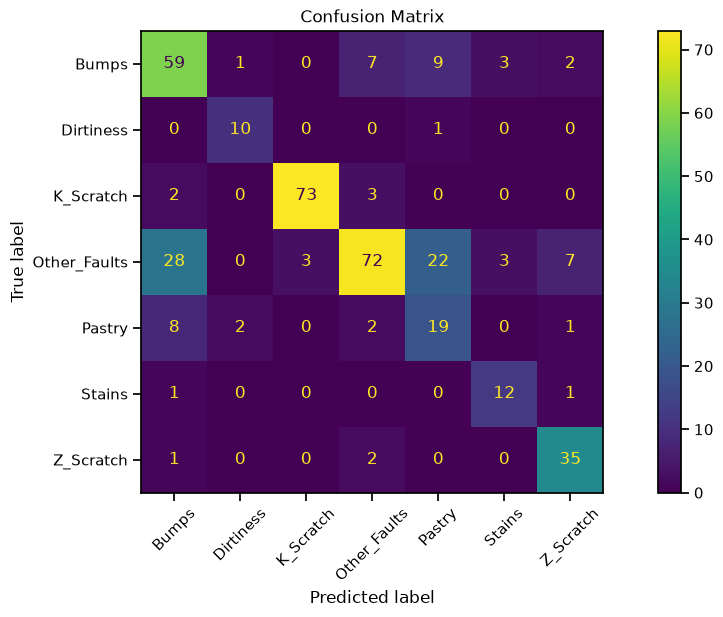

In [53]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,  display_labels = le.classes_)
fig, ax = plt.subplots()
fig.set_size_inches(14, 6)
disp.plot(ax = ax, xticks_rotation = 45)
plt.title('Confusion Matrix')
plt.show()

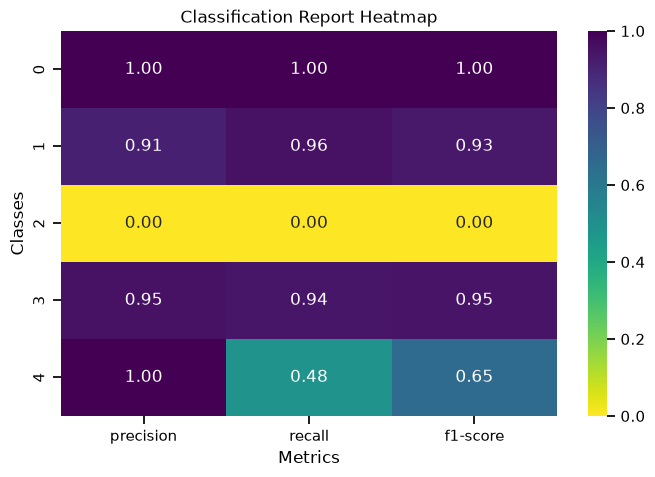

In [54]:
cr = classification_report(y_test, y_pred, zero_division = 0, output_dict = True)
cr_df = pd.DataFrame(cr).transpose()
heatmap_data = cr_df.iloc[: -3, :].drop(['support'], axis = 1)
plt.figure(figsize = (8, 5))
sns.heatmap(heatmap, annot = True, fmt = '.2f', cmap = 'viridis_r')
plt.title("Classification Report Heatmap")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.show()

# THOUGHT

Project: Fault in Plate Production.

what is it about? 

This project uses K-Nearest Neighbors (KNN), a supervised learning algorithm, to predict the type of fault (defect) in steel plates during production. The aim is to help in quality control, so faulty plates can be detected early.

How it works:

I imported all libraries that I needed to work with such as pandas, numpy, matplotlib, seaborn and scikit learn.

I loaded the dataset and went through it to understand it, and renamed columns. 

I checked for missing values, duplicates, and removed outliers by using the winsorization technique. And I checked the target column distribution, i noticed that there was class imbalance. 

I preprocess the data to convert categorical feature values to numbers, because machines only understand numbers.

I scaled the dataset to ensure that columns have values that are on the same scale.

I splitted my data into train and test which i used to fit and evaluate the performance of the algorithm used.

I applied **SMOTE** dataset was imbalanced and Knn performed poorly.

I used a for loop to train KNN, which i used to select the best K value from the given results.

Finally trained to look at past examples and learn data. 

The model can now take a new child's information and predict the nursery recommendation. 

KNN works like asking: To decide what kind of fault a new plate has, look at the k most similar plates in the past data. 

The majority fault type among them is assigned to the new plate.